# Notebook 09: RetailPulse Dashboard

## Objective

Build an interactive business dashboard that visualizes insights generated from previous notebooks.

### Dashboard Modules

- Sales Overview
- Customer Segmentation
- Sales Forecasting
- Customer Churn
- Inventory Optimization
- Recommendation System
- Business Recommendations

### Input Files

- retail_cleaned.csv
- customer_segments.csv
- forecast_results.csv
- high_risk_customers.csv
- inventory_summary.csv
- customer_product_recommendations.csv
- business_recommendations.csv

### Output

Interactive dashboard ready for Streamlit deployment.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [3]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"

print("Project Root :", PROJECT_ROOT)
print("Processed Data :", PROCESSED_DIR)
print("Reports :", REPORT_DIR)

Project Root : c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics
Processed Data : c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\data\processed
Reports : c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\reports


In [5]:
# ============================================================
# Load Dashboard Datasets
# ============================================================

# Main Processed Dataset
retail_df = pd.read_csv(
    PROCESSED_DIR / "retail_cleaned.csv",
    parse_dates=["InvoiceDate"]
)

# Customer Segmentation
segments_df = pd.read_csv(
    PROCESSED_DIR / "customer_segments.csv"
)

# Sales Forecasting
forecast_df = pd.read_csv(
    REPORT_DIR / "forecast_results.csv"
)

forecast_comparison_df = pd.read_csv(
    REPORT_DIR / "forecasting_model_comparison.csv"
)

# Customer Churn
churn_df = pd.read_csv(
    REPORT_DIR / "high_risk_customers.csv"
)

# Inventory
inventory_summary_df = pd.read_csv(
    REPORT_DIR / "inventory_summary.csv"
)

inventory_recommendation_df = pd.read_csv(
    REPORT_DIR / "inventory_recommendations.csv"
)

# Recommendation System
recommendation_df = pd.read_csv(
    REPORT_DIR / "customer_product_recommendations.csv"
)

# Business Recommendations
business_df = pd.read_csv(
    REPORT_DIR / "business_recommendations.csv"
)

print("=" * 60)
print("All Dashboard Datasets Loaded Successfully")
print("=" * 60)

print(f"Retail Data                 : {retail_df.shape}")
print(f"Customer Segments           : {segments_df.shape}")
print(f"Forecast Results            : {forecast_df.shape}")
print(f"Forecast Model Comparison   : {forecast_comparison_df.shape}")
print(f"High Risk Customers         : {churn_df.shape}")
print(f"Inventory Summary           : {inventory_summary_df.shape}")
print(f"Inventory Recommendations   : {inventory_recommendation_df.shape}")
print(f"Customer Recommendations    : {recommendation_df.shape}")
print(f"Business Recommendations    : {business_df.shape}")

All Dashboard Datasets Loaded Successfully
Retail Data                 : (779425, 22)
Customer Segments           : (5878, 3)
Forecast Results            : (142, 3)
Forecast Model Comparison   : (4, 3)
High Risk Customers         : (3414, 16)
Inventory Summary           : (5315, 7)
Inventory Recommendations   : (5315, 4)
Customer Recommendations    : (3414, 3)
Business Recommendations    : (5, 2)


In [6]:
# ============================================================
# Dashboard 1: Executive Overview
# ============================================================

# Sales KPIs
total_sales = retail_df["TotalAmount"].sum()
total_orders = retail_df["InvoiceID"].nunique()
total_customers = retail_df["CustomerID"].nunique()
total_products = retail_df["StockCode"].nunique()

average_order_value = (
    retail_df.groupby("InvoiceID")["TotalAmount"]
    .sum()
    .mean()
)

forecast_sales = forecast_df["PredictedSales"].sum()

high_risk_customers = churn_df["CustomerID"].nunique()

recommended_customers = recommendation_df["CustomerID"].nunique()

print("=" * 70)
print("              RETAILPULSE EXECUTIVE OVERVIEW")
print("=" * 70)

print(f"Total Sales                 : ₹{total_sales:,.2f}")
print(f"Total Orders                : {total_orders:,}")
print(f"Total Customers             : {total_customers:,}")
print(f"Total Products              : {total_products:,}")
print(f"Average Order Value         : ₹{average_order_value:,.2f}")
print(f"Forecasted Sales            : ₹{forecast_sales:,.2f}")
print(f"High-Risk Customers         : {high_risk_customers:,}")
print(f"Customers Recommended       : {recommended_customers:,}")

print("=" * 70)

              RETAILPULSE EXECUTIVE OVERVIEW
Total Sales                 : ₹17,374,804.27
Total Orders                : 36,969
Total Customers             : 5,878
Total Products              : 4,631
Average Order Value         : ₹469.98
Forecasted Sales            : ₹4,461,221.47
High-Risk Customers         : 3,414
Customers Recommended       : 3,414


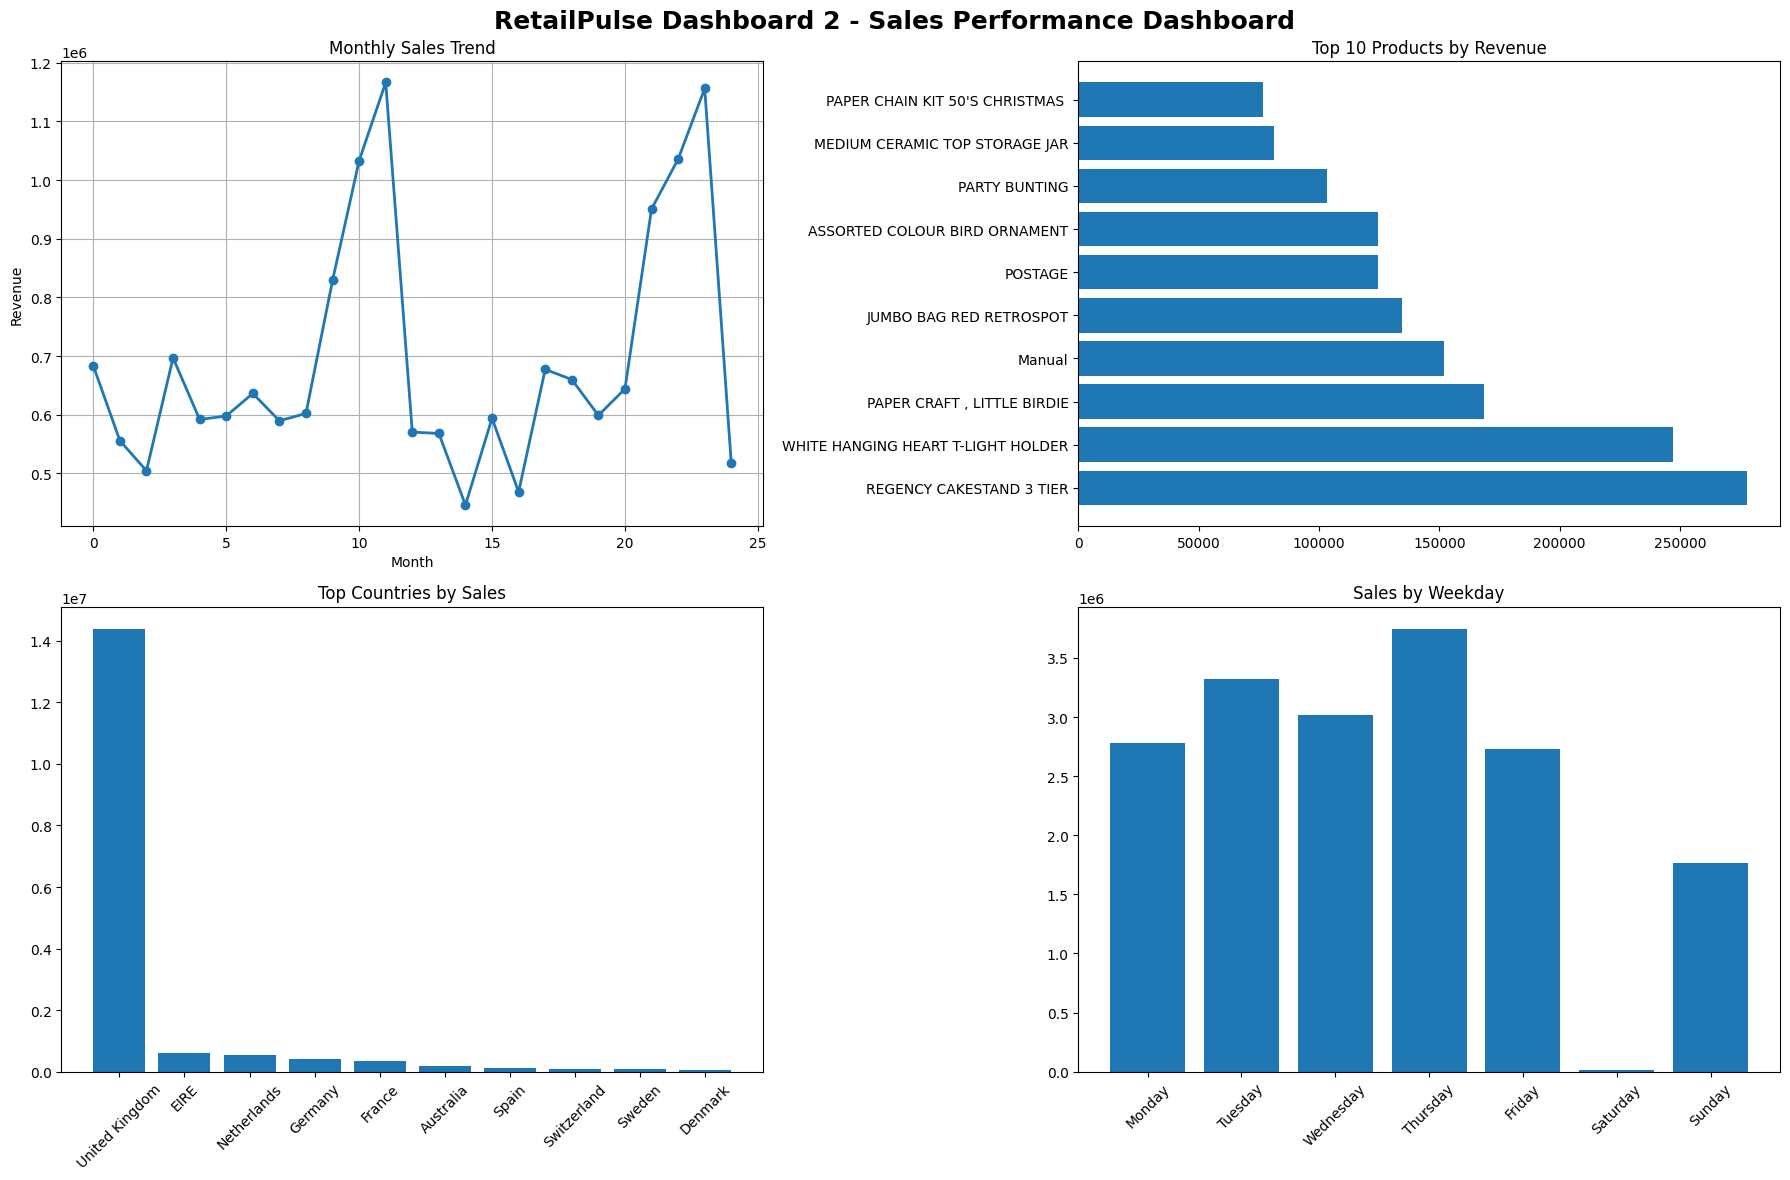

In [10]:
# ============================================================
# Dashboard 2: Sales Performance Dashboard
# ============================================================

# Additional Date Features
retail_df["Year"] = retail_df["InvoiceDate"].dt.year
retail_df["Month"] = retail_df["InvoiceDate"].dt.month_name()
retail_df["MonthNum"] = retail_df["InvoiceDate"].dt.month
retail_df["Weekday"] = retail_df["InvoiceDate"].dt.day_name()

# Monthly Sales
monthly_sales = (
    retail_df.groupby(["Year", "MonthNum", "Month"])["TotalAmount"]
    .sum()
    .reset_index()
)

# Top 10 Products
top_products = (
    retail_df.groupby("ProductDescription")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Top 10 Countries
top_countries = (
    retail_df.groupby("CustomerCountry")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Weekday Sales
weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

weekday_sales = (
    retail_df.groupby("Weekday")["TotalAmount"]
    .sum()
    .reindex(weekday_order)
)

# ============================================================
# Plot Dashboard
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Monthly Sales Trend
axes[0,0].plot(
    range(len(monthly_sales)),
    monthly_sales["TotalAmount"],
    marker="o",
    linewidth=2
)
axes[0,0].set_title("Monthly Sales Trend")
axes[0,0].set_xlabel("Month")
axes[0,0].set_ylabel("Revenue")
axes[0,0].grid(True)

# Top Products
axes[0,1].barh(
    top_products.index,
    top_products.values
)
axes[0,1].set_title("Top 10 Products by Revenue")

# Top Countries
axes[1,0].bar(
    top_countries.index,
    top_countries.values
)
axes[1,0].set_title("Top Countries by Sales")
axes[1,0].tick_params(axis="x", rotation=45)

# Weekday Sales
axes[1,1].bar(
    weekday_sales.index,
    weekday_sales.values
)
axes[1,1].set_title("Sales by Weekday")
axes[1,1].tick_params(axis="x", rotation=45)
plt.suptitle(
    "RetailPulse Dashboard 2 - Sales Performance Dashboard",
    fontsize=18,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

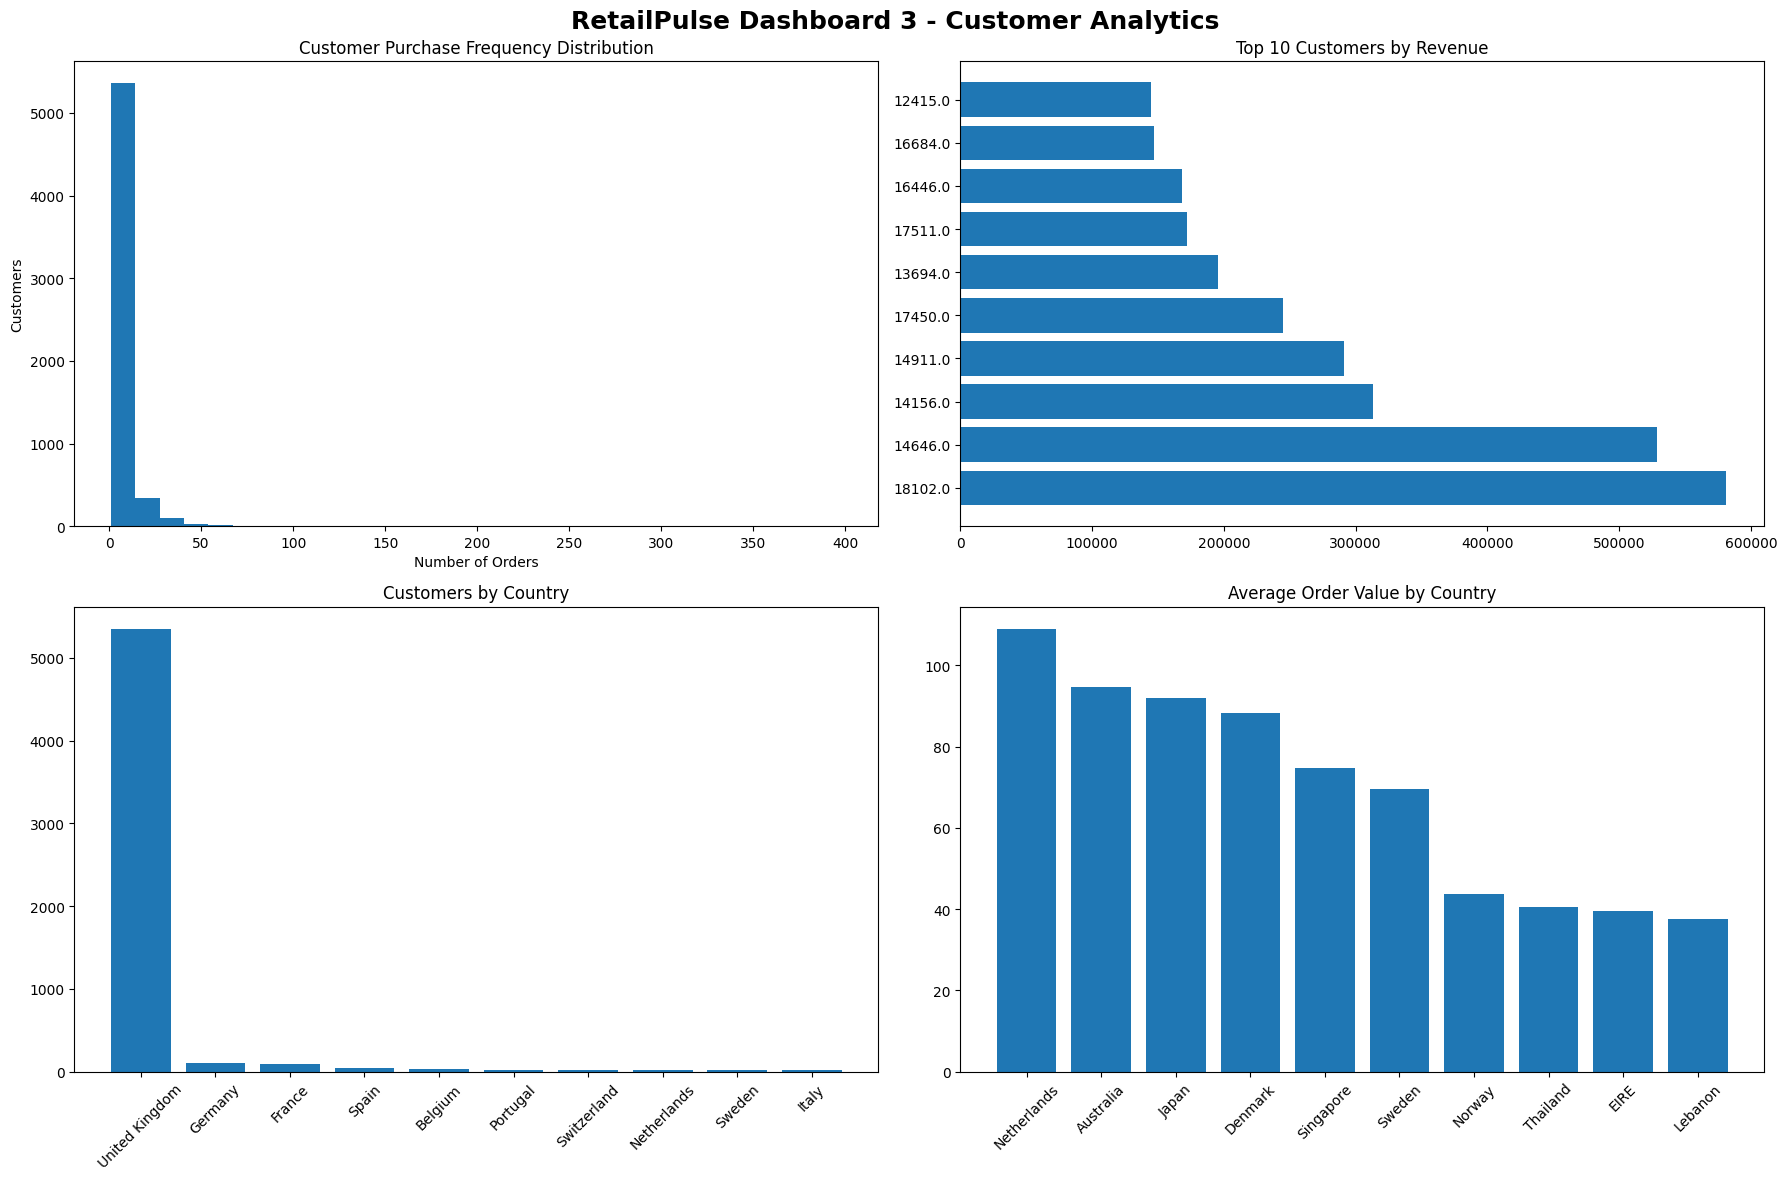

In [9]:
# ============================================================
# Dashboard 3: Customer Analytics Dashboard
# ============================================================

# Customer Purchase Frequency
purchase_frequency = (
    retail_df.groupby("CustomerID")["InvoiceID"]
    .nunique()
    .sort_values(ascending=False)
)

# Top 10 Customers by Revenue
top_customers = (
    retail_df.groupby("CustomerID")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Customer Distribution by Country
customer_country = (
    retail_df.groupby("CustomerCountry")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

# Average Order Value by Country
avg_order_country = (
    retail_df.groupby("CustomerCountry")["TotalAmount"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# ============================================================
# Plot Dashboard
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Purchase Frequency Distribution
axes[0,0].hist(
    purchase_frequency,
    bins=30
)
axes[0,0].set_title("Customer Purchase Frequency Distribution")
axes[0,0].set_xlabel("Number of Orders")
axes[0,0].set_ylabel("Customers")

# Top Customers
axes[0,1].barh(
    top_customers.index.astype(str),
    top_customers.values
)
axes[0,1].set_title("Top 10 Customers by Revenue")

# Customer Distribution by Country
axes[1,0].bar(
    customer_country.index,
    customer_country.values
)
axes[1,0].set_title("Customers by Country")
axes[1,0].tick_params(axis="x", rotation=45)

# Average Order Value by Country
axes[1,1].bar(
    avg_order_country.index,
    avg_order_country.values
)
axes[1,1].set_title("Average Order Value by Country")
axes[1,1].tick_params(axis="x", rotation=45)

plt.suptitle(
    "RetailPulse Dashboard 3 - Customer Analytics",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

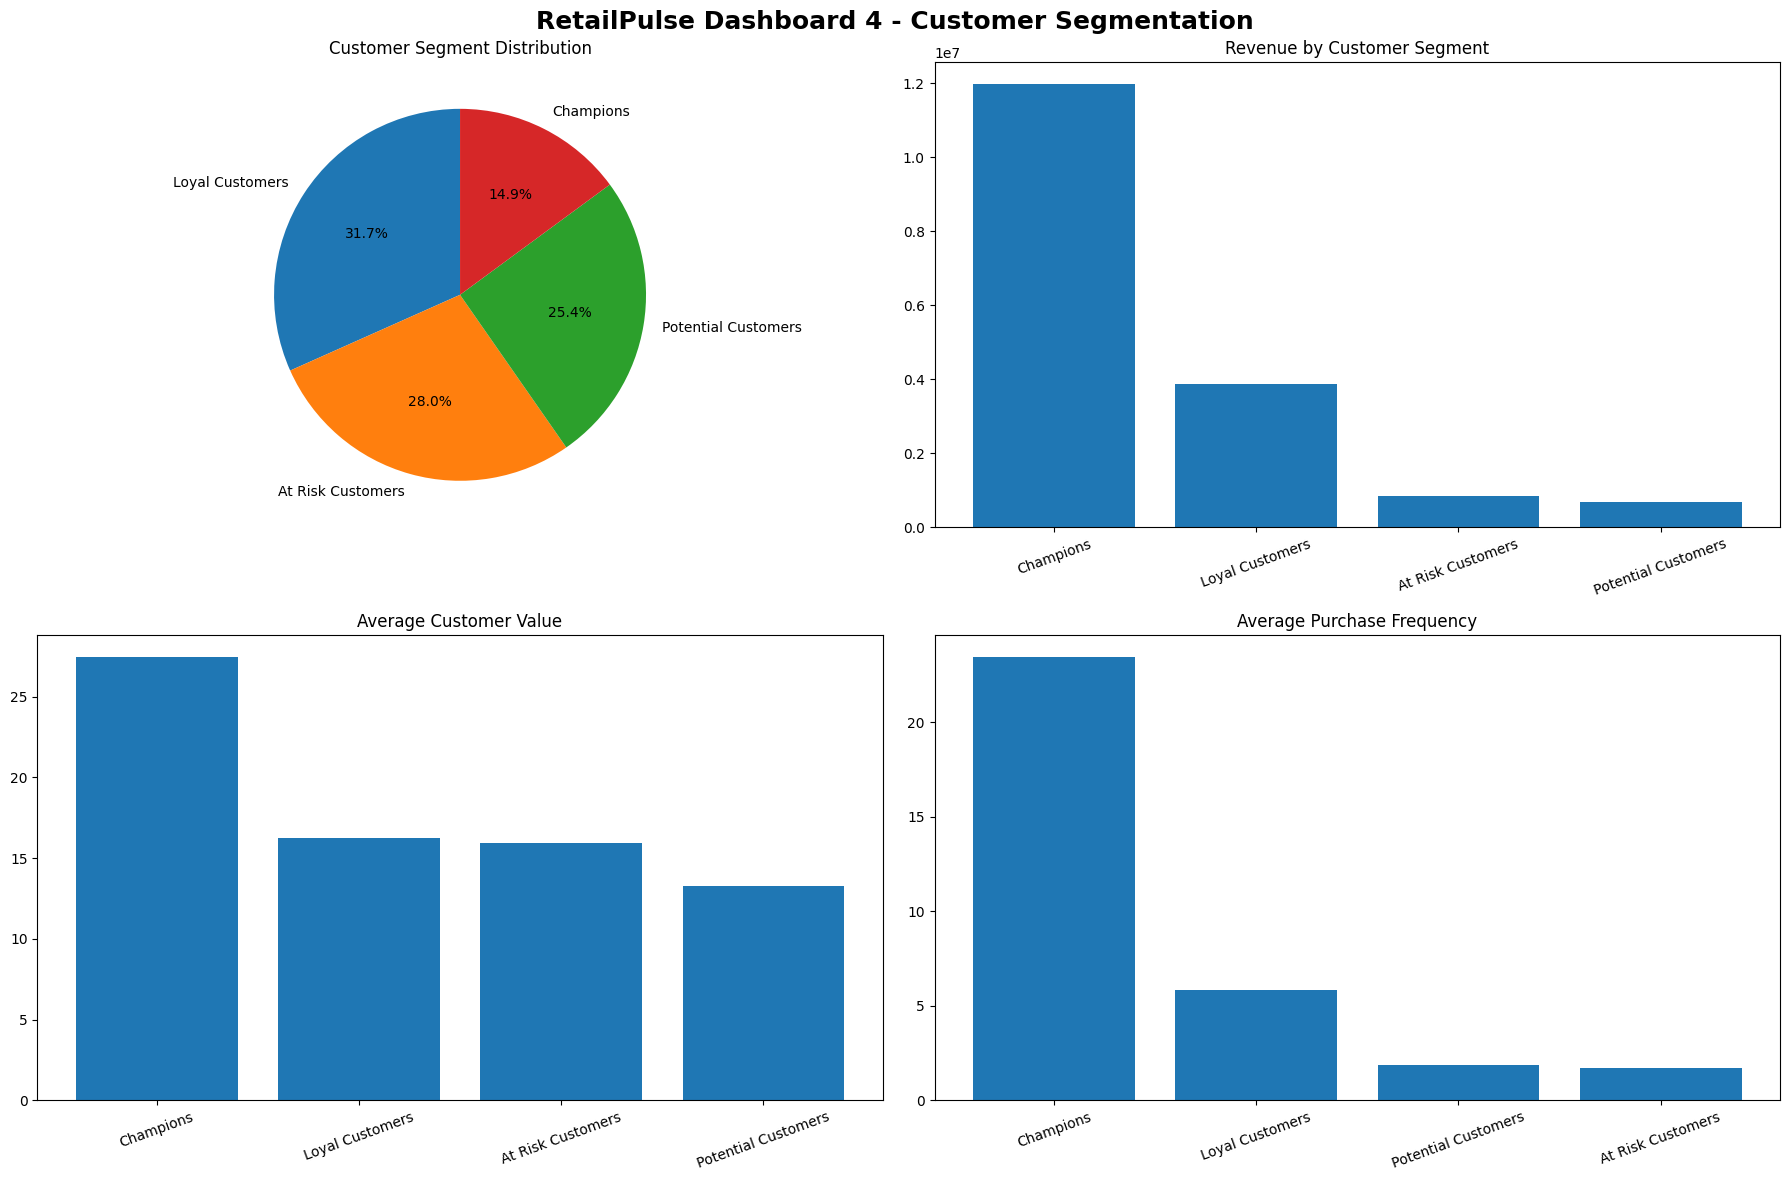

In [12]:
# ============================================================
# Dashboard 4: Customer Segmentation Dashboard
# ============================================================

# Merge customer segments with retail data
segment_analysis = retail_df.merge(
    segments_df,
    on="CustomerID",
    how="inner"
)

# Segment Distribution
segment_distribution = (
    segments_df["Segment"]
    .value_counts()
)

# Revenue by Segment
segment_revenue = (
    segment_analysis.groupby("Segment")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

# Average Customer Value
avg_customer_value = (
    segment_analysis.groupby("Segment")["TotalAmount"]
    .mean()
    .sort_values(ascending=False)
)

# Purchase Frequency by Segment
purchase_frequency = (
    segment_analysis.groupby(["Segment", "CustomerID"])["InvoiceID"]
    .nunique()
    .reset_index()
)

avg_purchase_frequency = (
    purchase_frequency.groupby("Segment")["InvoiceID"]
    .mean()
    .sort_values(ascending=False)
)

# ============================================================
# Plot Dashboard
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Customer Segment Distribution
axes[0,0].pie(
    segment_distribution.values,
    labels=segment_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[0,0].set_title("Customer Segment Distribution")

# 2. Revenue Contribution
axes[0,1].bar(
    segment_revenue.index,
    segment_revenue.values
)
axes[0,1].set_title("Revenue by Customer Segment")
axes[0,1].tick_params(axis="x", rotation=20)

# 3. Average Customer Value
axes[1,0].bar(
    avg_customer_value.index,
    avg_customer_value.values
)
axes[1,0].set_title("Average Customer Value")
axes[1,0].tick_params(axis="x", rotation=20)

# 4. Average Purchase Frequency
axes[1,1].bar(
    avg_purchase_frequency.index,
    avg_purchase_frequency.values
)
axes[1,1].set_title("Average Purchase Frequency")
axes[1,1].tick_params(axis="x", rotation=20)

plt.suptitle(
    "RetailPulse Dashboard 4 - Customer Segmentation",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

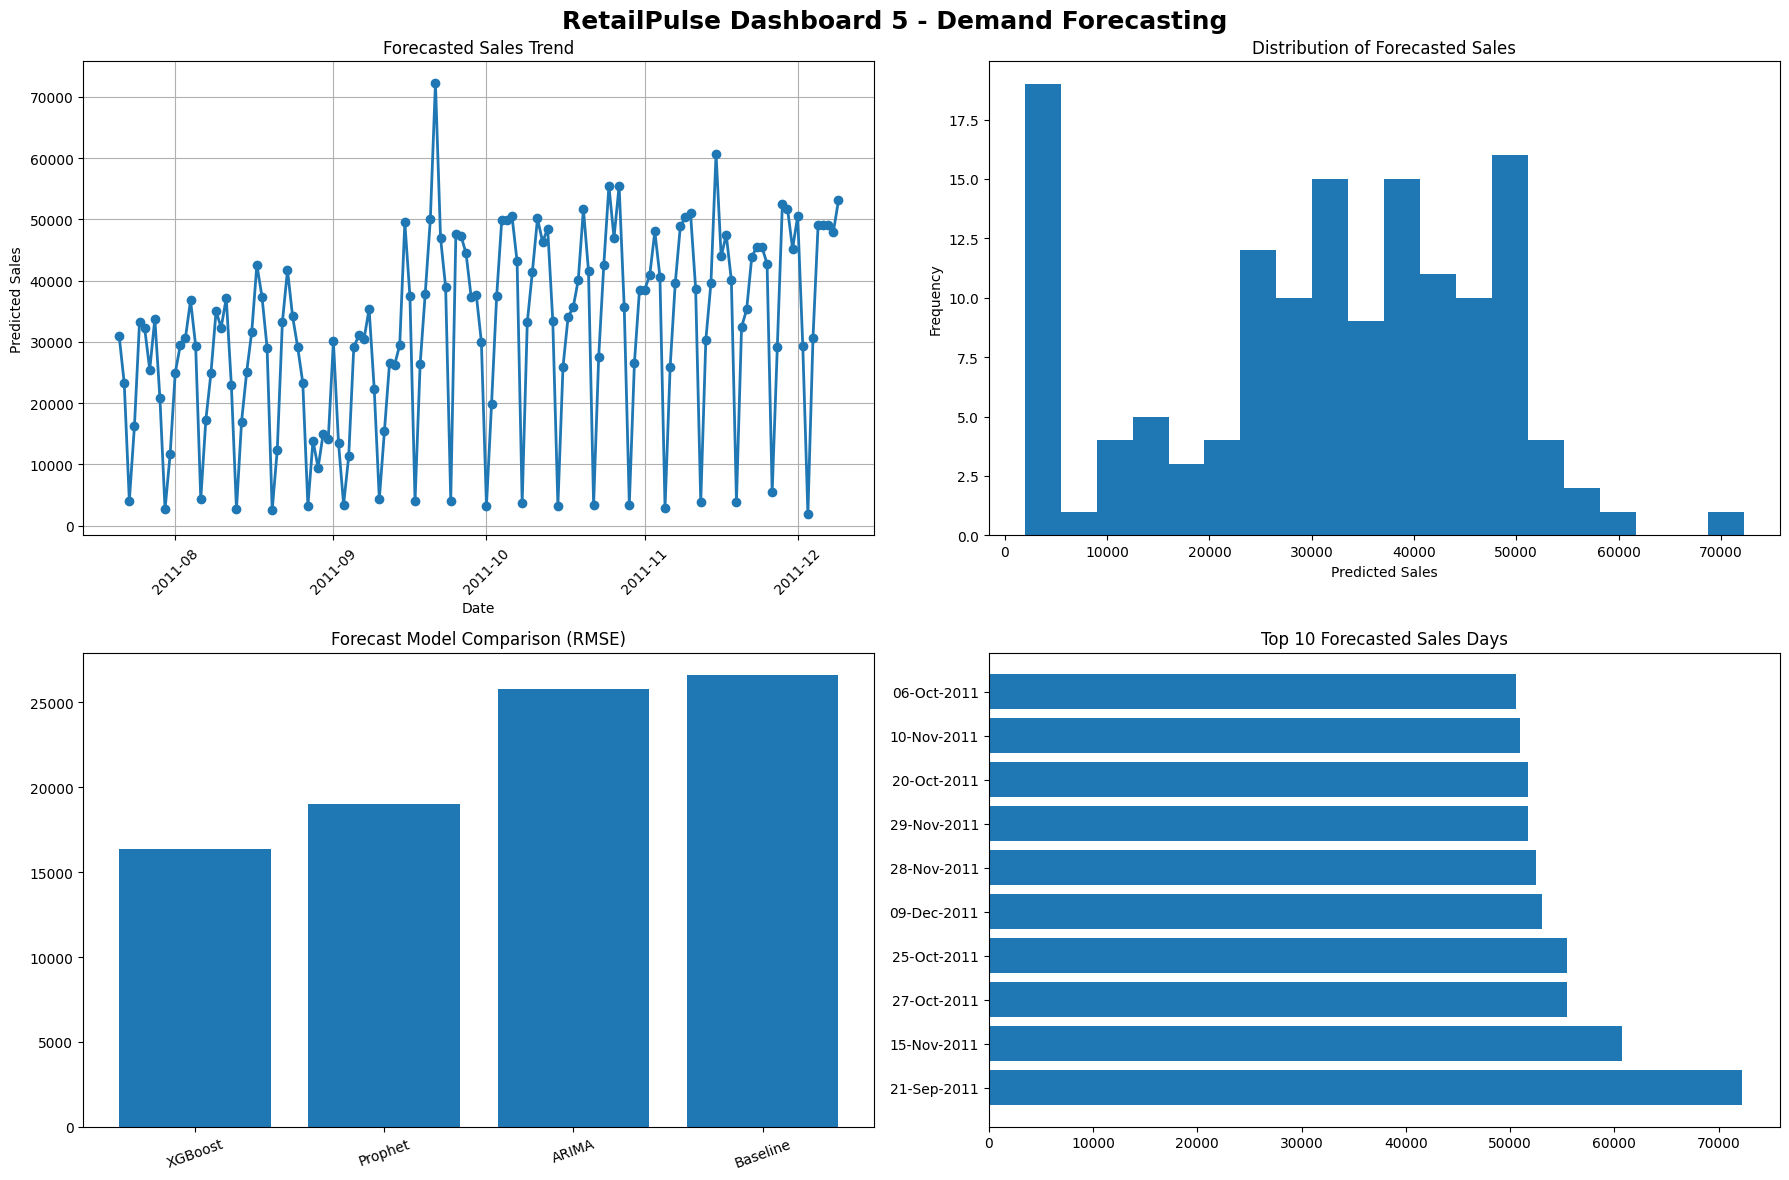

In [11]:
# ============================================================
# Dashboard 5: Demand Forecasting
# ============================================================

# Ensure date column is datetime
forecast_df["Date"] = pd.to_datetime(forecast_df["Date"])

# ============================================================
# Create Dashboard
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Forecasted Sales Trend
axes[0, 0].plot(
    forecast_df["Date"],
    forecast_df["PredictedSales"],
    marker="o",
    linewidth=2
)
axes[0, 0].set_title("Forecasted Sales Trend")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Predicted Sales")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(True)

# 2. Predicted Sales Distribution
axes[0, 1].hist(
    forecast_df["PredictedSales"],
    bins=20
)
axes[0, 1].set_title("Distribution of Forecasted Sales")
axes[0, 1].set_xlabel("Predicted Sales")
axes[0, 1].set_ylabel("Frequency")

# 3. Model Comparison
axes[1, 0].bar(
    forecast_comparison_df["Model"],
    forecast_comparison_df["RMSE"]
)
axes[1, 0].set_title("Forecast Model Comparison (RMSE)")
axes[1, 0].tick_params(axis="x", rotation=20)

# 4. Top Forecast Days
top_forecast = (
    forecast_df.sort_values(
        "PredictedSales",
        ascending=False
    )
    .head(10)
)

axes[1, 1].barh(
    top_forecast["Date"].dt.strftime("%d-%b-%Y"),
    top_forecast["PredictedSales"]
)

axes[1, 1].set_title("Top 10 Forecasted Sales Days")

plt.suptitle(
    "RetailPulse Dashboard 5 - Demand Forecasting",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

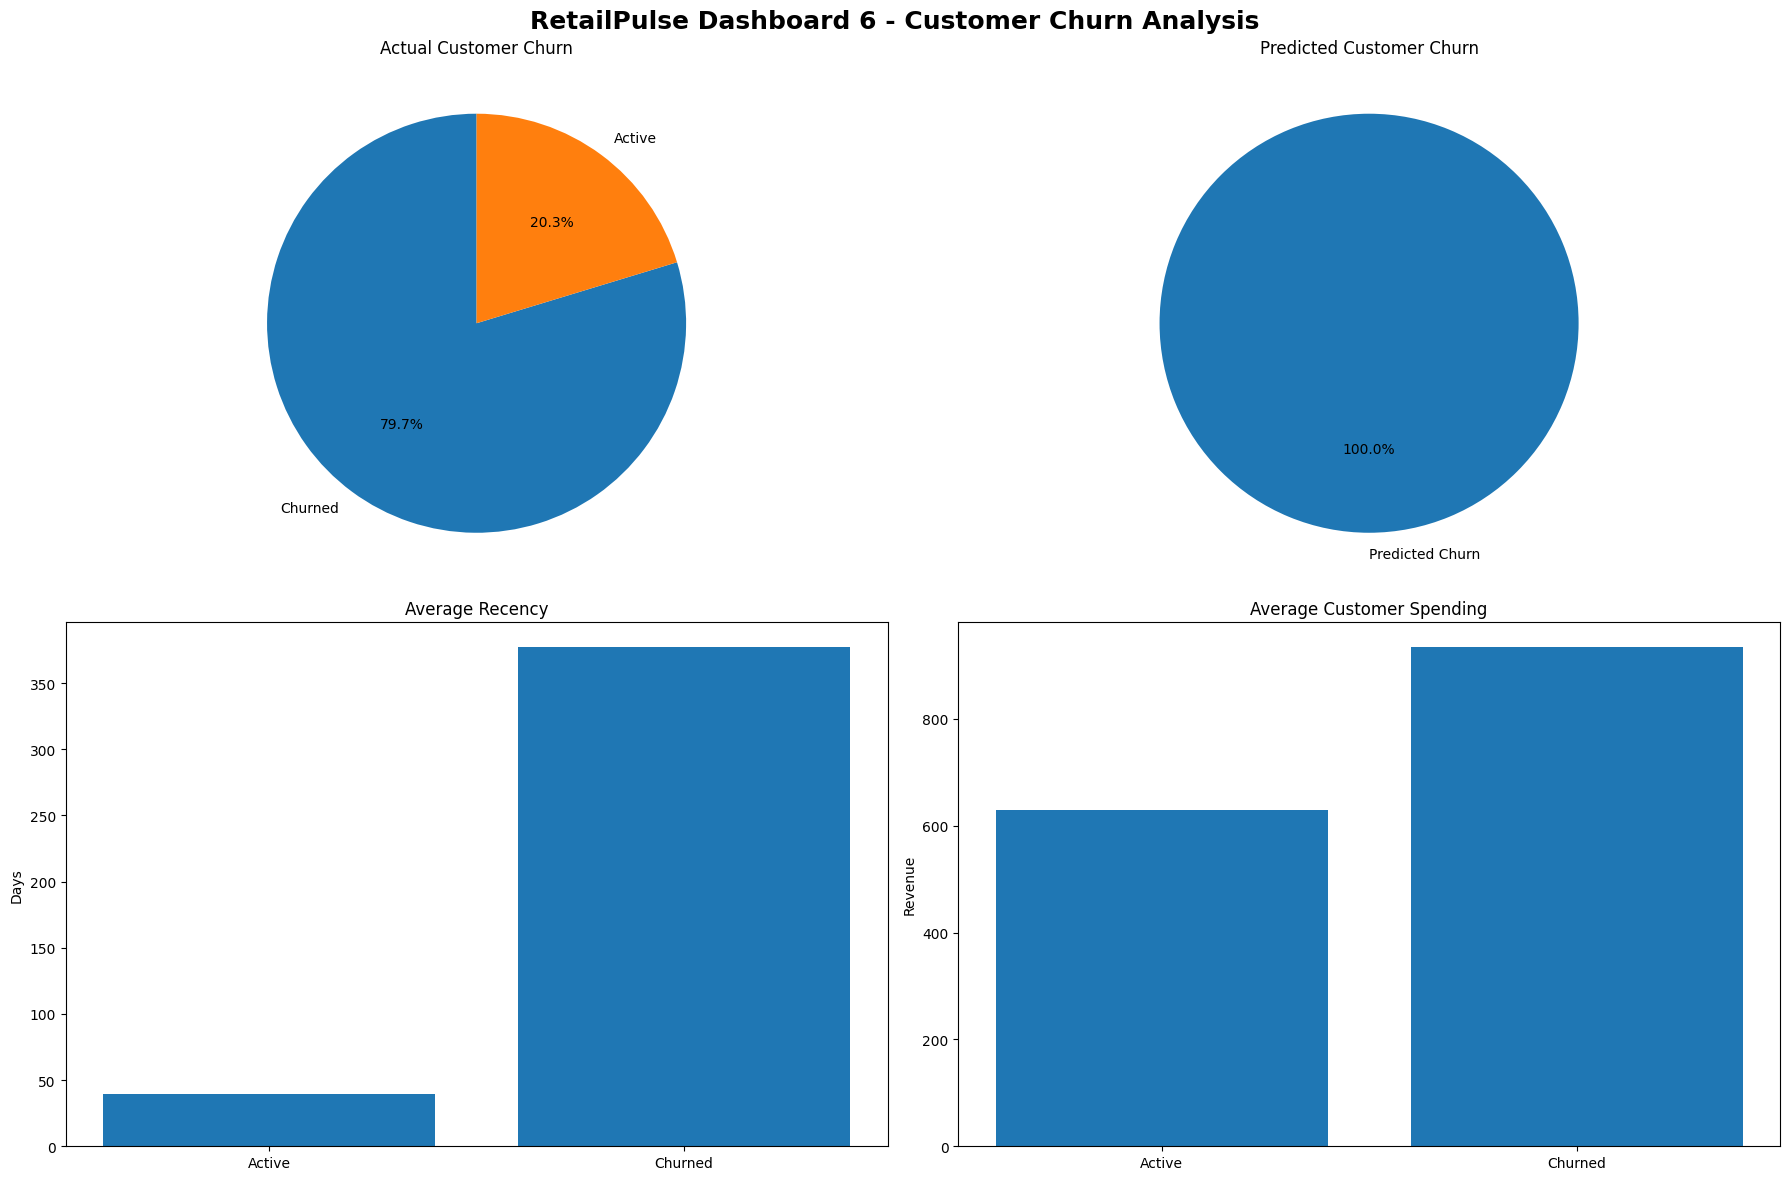

In [19]:
# ============================================================
# Dashboard 6: Customer Churn Analysis
# ============================================================

# Create labels
churn_df["ActualStatus"] = churn_df["Churn"].map({
    0: "Active",
    1: "Churned"
})

churn_df["PredictedStatus"] = churn_df["PredictedChurn"].map({
    0: "Active",
    1: "Predicted Churn"
})

# Actual churn distribution
actual_distribution = (
    churn_df["ActualStatus"]
    .value_counts()
)

# Predicted churn distribution
predicted_distribution = (
    churn_df["PredictedStatus"]
    .value_counts()
)

# Average Recency
avg_recency = (
    churn_df.groupby("ActualStatus")["Recency"]
    .mean()
)

# Average Monetary
avg_monetary = (
    churn_df.groupby("ActualStatus")["Monetary"]
    .mean()
)

# ============================================================
# Plot Dashboard
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Actual Churn Distribution
axes[0,0].pie(
    actual_distribution.values,
    labels=actual_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[0,0].set_title("Actual Customer Churn")

# 2. Predicted Churn Distribution
axes[0,1].pie(
    predicted_distribution.values,
    labels=predicted_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[0,1].set_title("Predicted Customer Churn")

# 3. Average Recency
axes[1,0].bar(
    avg_recency.index,
    avg_recency.values
)
axes[1,0].set_title("Average Recency")
axes[1,0].set_ylabel("Days")

# 4. Average Monetary Value
axes[1,1].bar(
    avg_monetary.index,
    avg_monetary.values
)
axes[1,1].set_title("Average Customer Spending")
axes[1,1].set_ylabel("Revenue")

plt.suptitle(
    "RetailPulse Dashboard 6 - Customer Churn Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

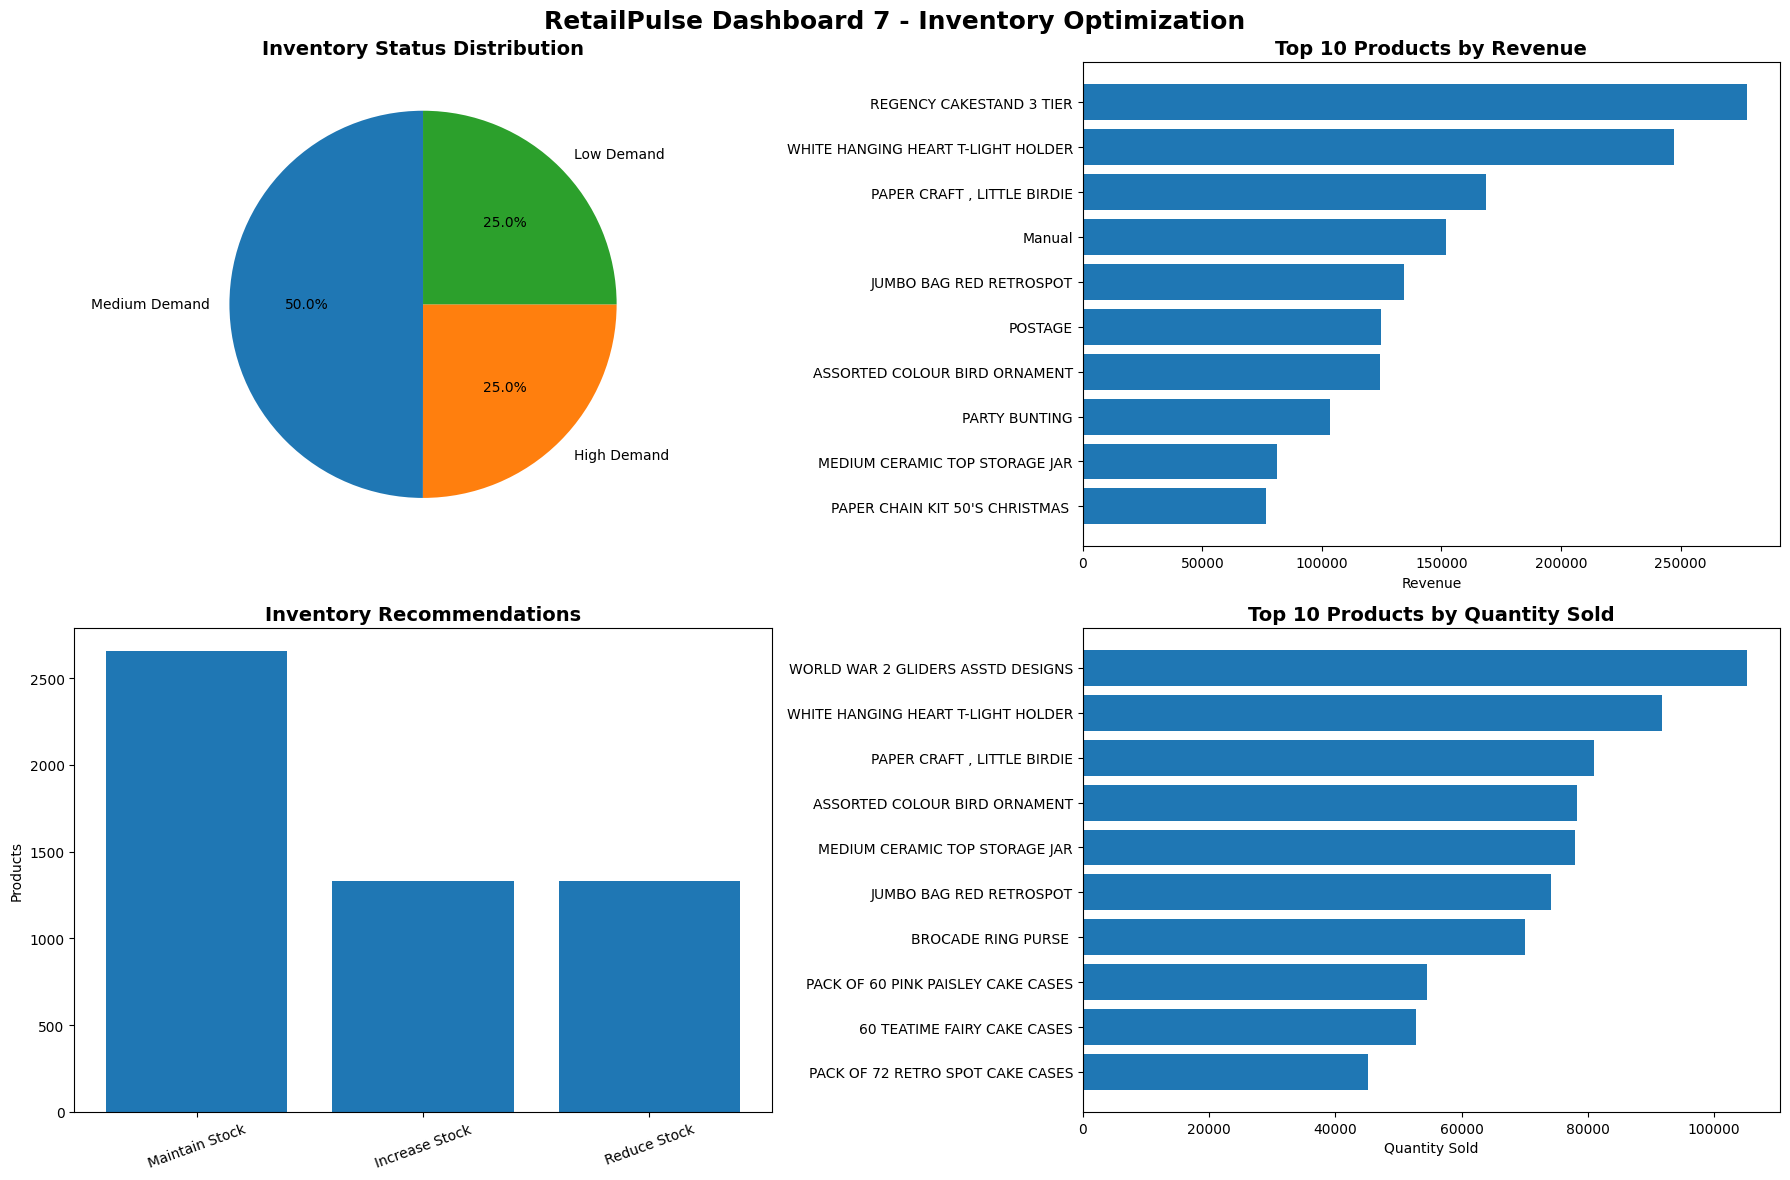

In [22]:
# ============================================================
# Dashboard 7 : Inventory Optimization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ============================================================
# 1. Inventory Status Distribution
# ============================================================

status_counts = inventory_df["InventoryStatus"].value_counts()

axes[0,0].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

axes[0,0].set_title(
    "Inventory Status Distribution",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# 2. Top 10 Products by Revenue
# ============================================================

top_revenue = (
    inventory_df
    .sort_values("TotalRevenue", ascending=False)
    .head(10)
)

axes[0,1].barh(
    top_revenue["ProductDescription"],
    top_revenue["TotalRevenue"]
)

axes[0,1].invert_yaxis()

axes[0,1].set_title(
    "Top 10 Products by Revenue",
    fontsize=14,
    fontweight="bold"
)

axes[0,1].set_xlabel("Revenue")

# ============================================================
# 3. Recommendation Distribution
# ============================================================

recommendation_counts = (
    inventory_recommendation_df["Recommendation"]
    .value_counts()
)

axes[1,0].bar(
    recommendation_counts.index,
    recommendation_counts.values
)

axes[1,0].set_title(
    "Inventory Recommendations",
    fontsize=14,
    fontweight="bold"
)

axes[1,0].set_ylabel("Products")

axes[1,0].tick_params(axis="x", rotation=20)

# ============================================================
# 4. Top 10 Products by Quantity Sold
# ============================================================

top_quantity = (
    inventory_df
    .sort_values("TotalQuantity", ascending=False)
    .head(10)
)

axes[1,1].barh(
    top_quantity["ProductDescription"],
    top_quantity["TotalQuantity"]
)

axes[1,1].invert_yaxis()

axes[1,1].set_title(
    "Top 10 Products by Quantity Sold",
    fontsize=14,
    fontweight="bold"
)

axes[1,1].set_xlabel("Quantity Sold")

# ============================================================
# Dashboard Title
# ============================================================

plt.suptitle(
    "RetailPulse Dashboard 7 - Inventory Optimization",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

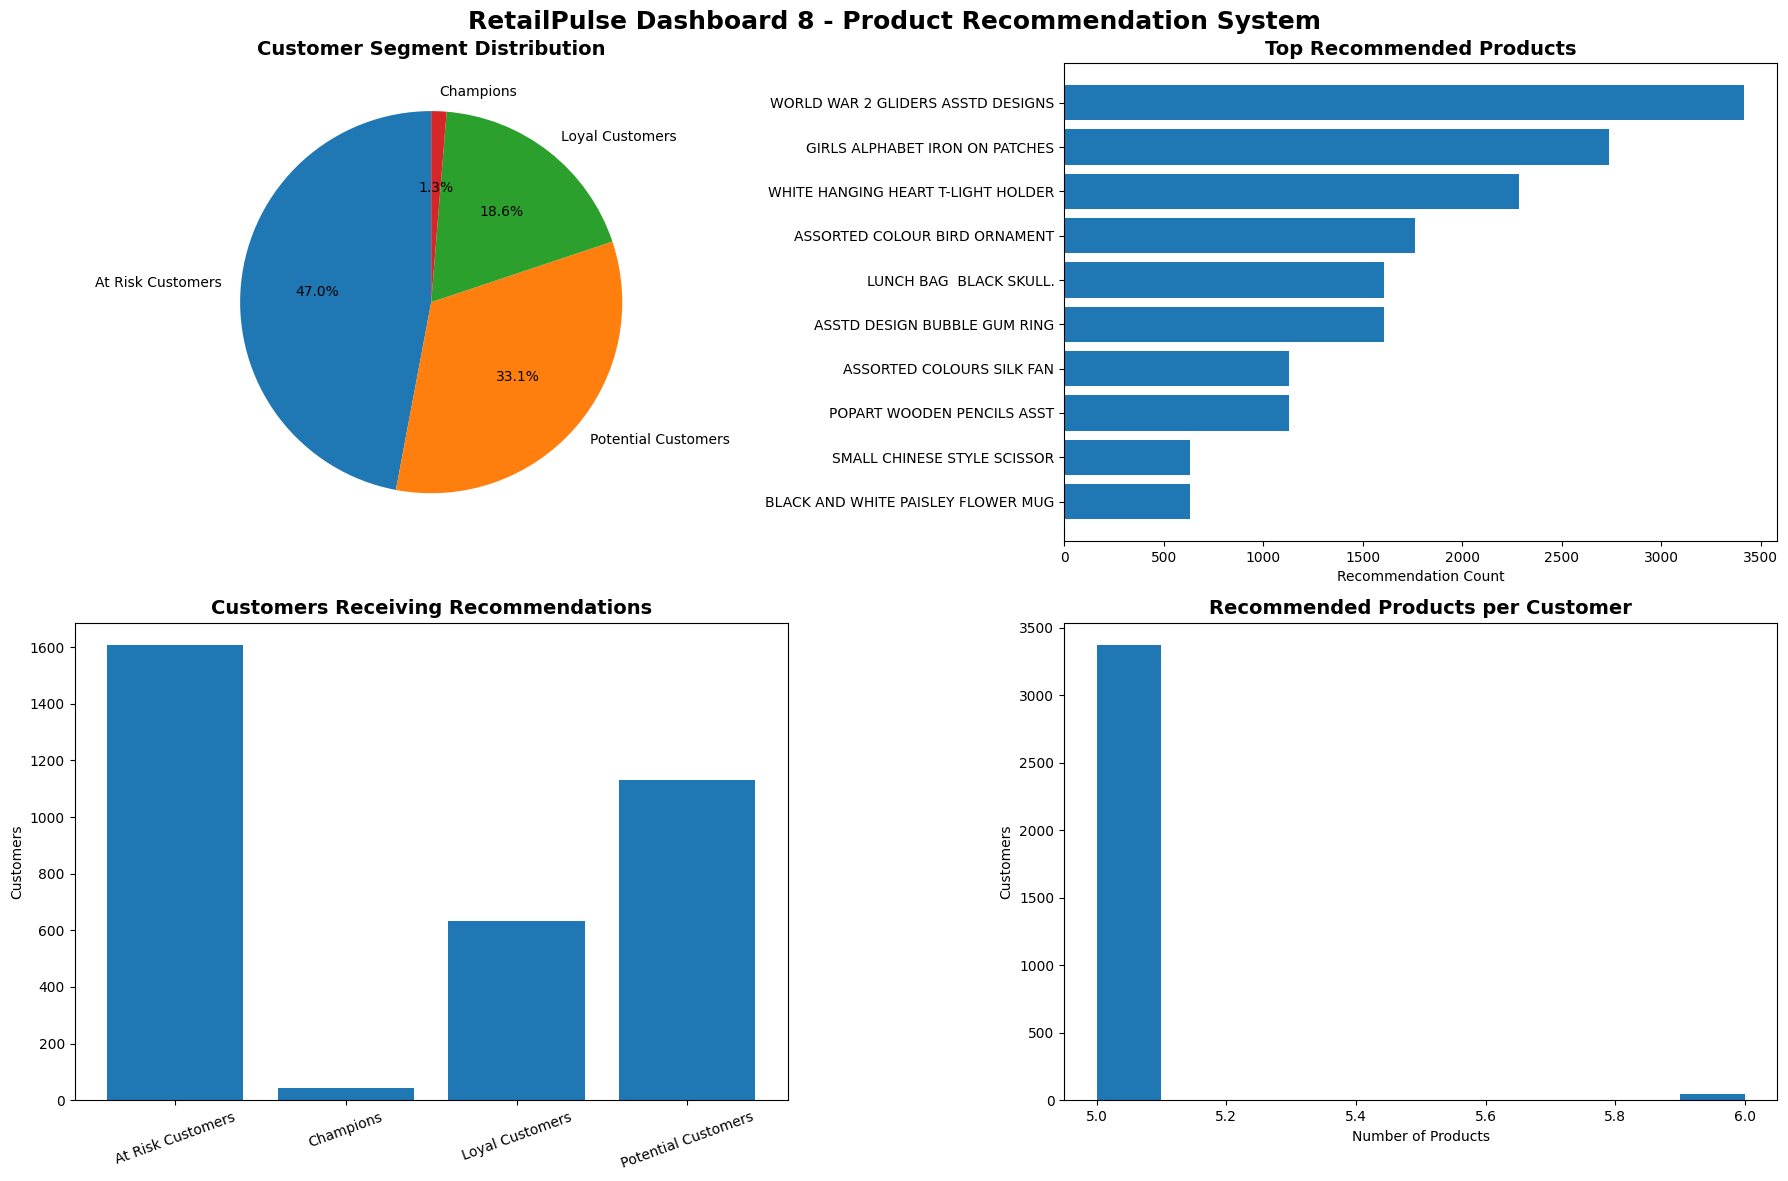

In [28]:
# ============================================================
# Dashboard 8 : Product Recommendation System
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ============================================================
# 1. Customer Segment Distribution
# ============================================================

segment_counts = recommendation_df["Segment"].value_counts()

axes[0,0].pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

axes[0,0].set_title(
    "Customer Segment Distribution",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# 2. Top Recommended Products
# ============================================================

top_products = (
    recommendation_df["RecommendedProducts"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

axes[0,1].barh(
    top_products.index,
    top_products.values
)

axes[0,1].invert_yaxis()

axes[0,1].set_title(
    "Top Recommended Products",
    fontsize=14,
    fontweight="bold"
)

axes[0,1].set_xlabel("Recommendation Count")

# ============================================================
# 3. Customers by Segment
# ============================================================

customer_counts = (
    recommendation_df.groupby("Segment")["CustomerID"]
    .nunique()
)

axes[1,0].bar(
    customer_counts.index,
    customer_counts.values
)

axes[1,0].set_title(
    "Customers Receiving Recommendations",
    fontsize=14,
    fontweight="bold"
)

axes[1,0].set_ylabel("Customers")

axes[1,0].tick_params(axis="x", rotation=20)

# ============================================================
# 4. Number of Recommended Products per Customer
# ============================================================

recommendation_df["RecommendationCount"] = (
    recommendation_df["RecommendedProducts"]
    .str.count(",") + 1
)

axes[1,1].hist(
    recommendation_df["RecommendationCount"],
    bins=10
)

axes[1,1].set_title(
    "Recommended Products per Customer",
    fontsize=14,
    fontweight="bold"
)

axes[1,1].set_xlabel("Number of Products")
axes[1,1].set_ylabel("Customers")

# ============================================================
# Dashboard Title
# ============================================================

plt.suptitle(
    "RetailPulse Dashboard 8 - Product Recommendation System",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

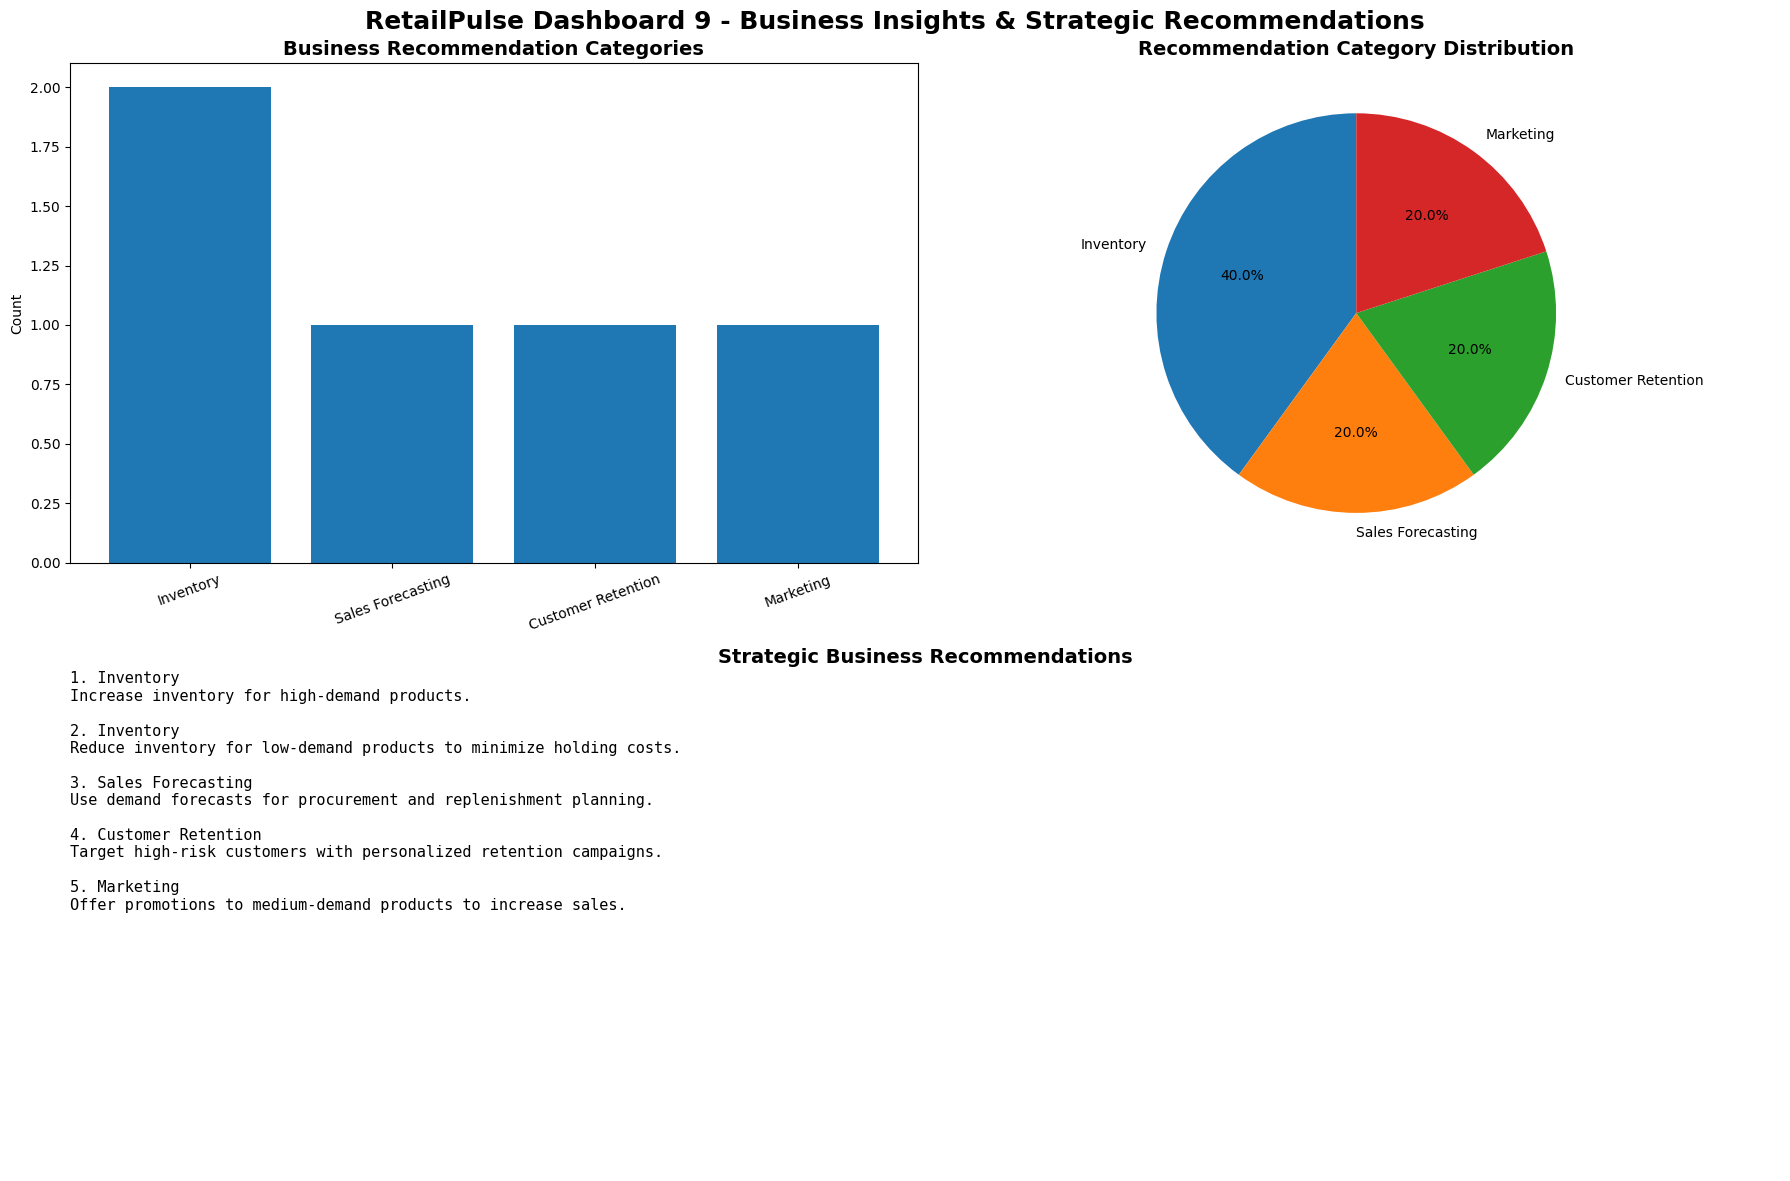

In [30]:
# ============================================================
# Dashboard 9 : Business Insights & Strategic Recommendations
# ============================================================

import textwrap

fig = plt.figure(figsize=(18,12))

# ============================================================
# 1. Business Recommendation Categories
# ============================================================

ax1 = plt.subplot2grid((2,2), (0,0))

category_counts = business_df["Category"].value_counts()

ax1.bar(
    category_counts.index,
    category_counts.values
)

ax1.set_title(
    "Business Recommendation Categories",
    fontsize=14,
    fontweight="bold"
)

ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=20)

# ============================================================
# 2. Category Distribution
# ============================================================

ax2 = plt.subplot2grid((2,2), (0,1))

ax2.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

ax2.set_title(
    "Recommendation Category Distribution",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# 3. Strategic Recommendations
# ============================================================

ax3 = plt.subplot2grid((2,2), (1,0), colspan=2)

ax3.axis("off")

text = ""

for i, row in business_df.iterrows():
    wrapped = textwrap.fill(
        row["Recommendation"],
        width=110
    )

    text += (
        f"{i+1}. {row['Category']}\n"
        f"{wrapped}\n\n"
    )

ax3.text(
    0,
    1,
    text,
    fontsize=11,
    va="top",
    family="monospace"
)

ax3.set_title(
    "Strategic Business Recommendations",
    fontsize=14,
    fontweight="bold"
)

plt.suptitle(
    "RetailPulse Dashboard 9 - Business Insights & Strategic Recommendations",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

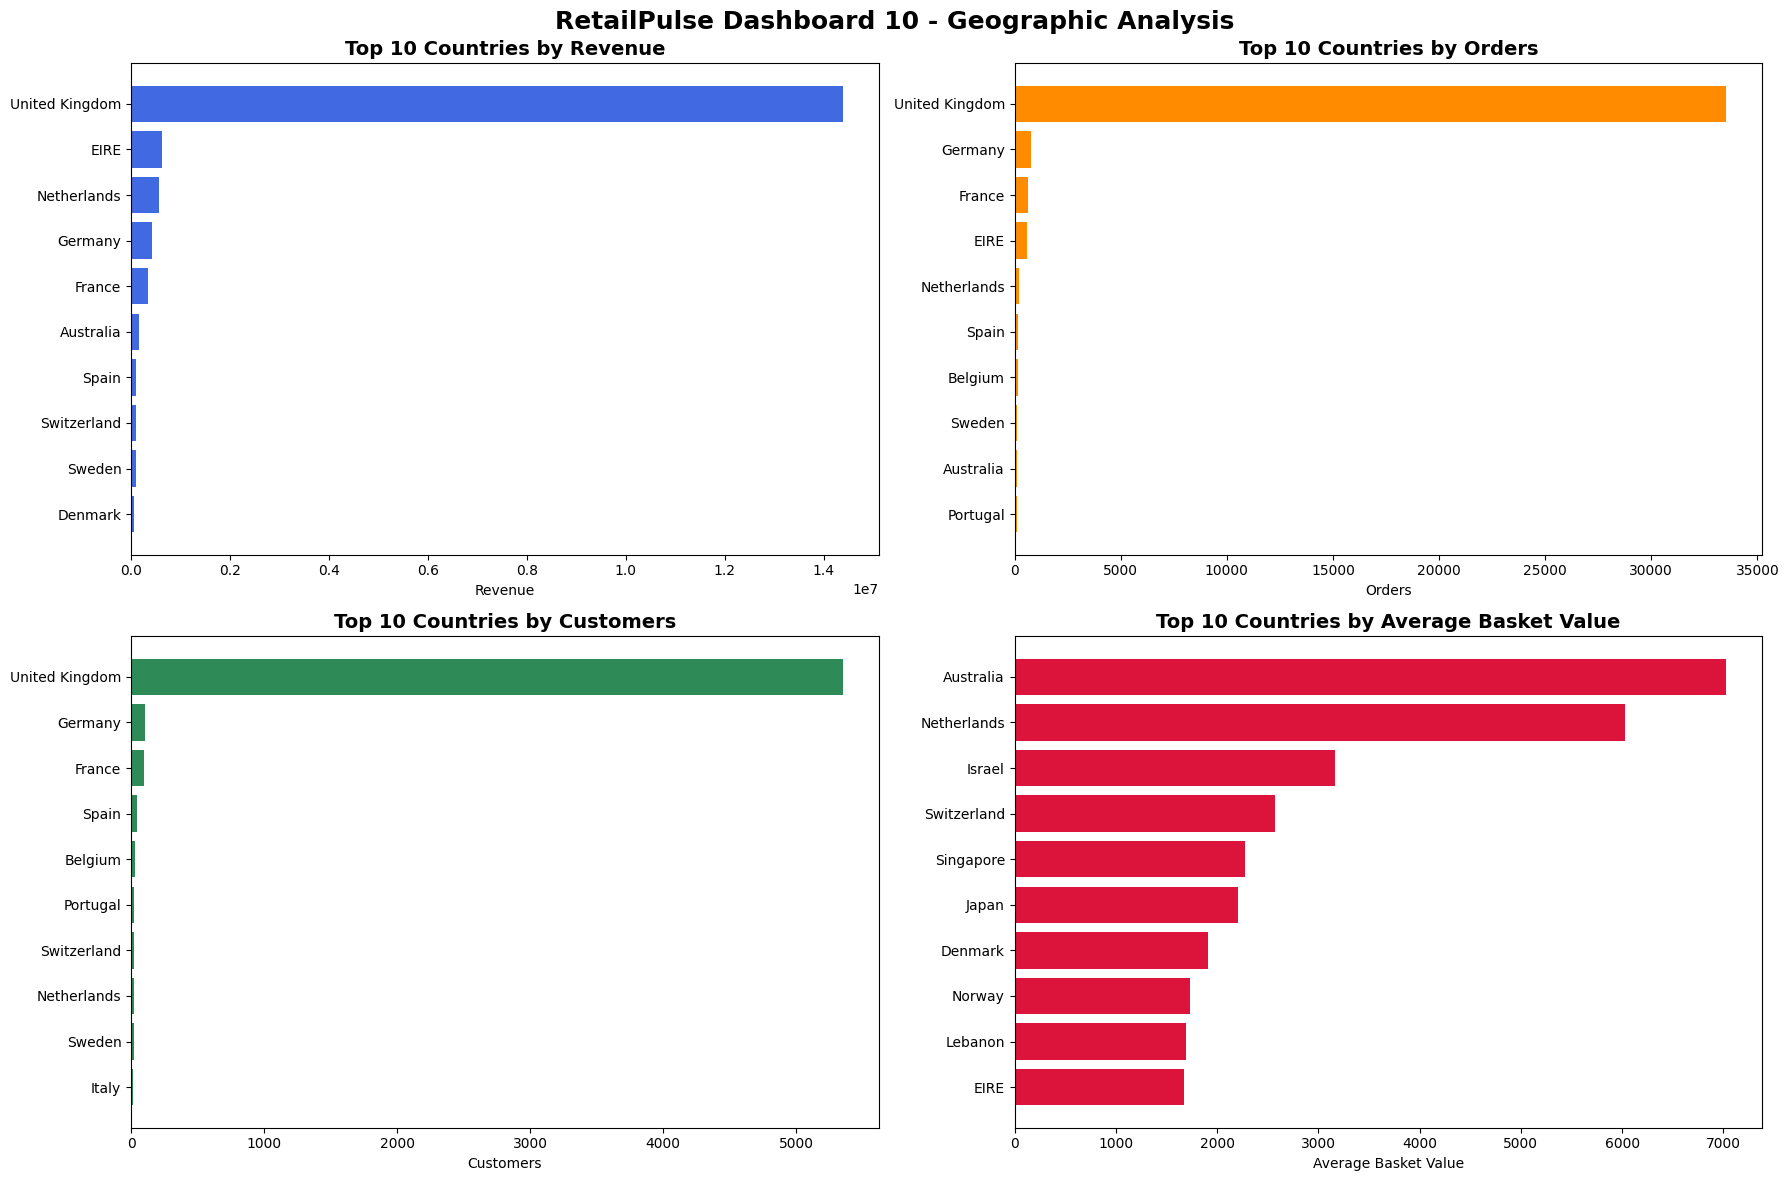

In [33]:
# ============================================================
# Dashboard 10 : Geographic Analysis
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18,12))

# ============================================================
# 1. Top 10 Countries by Revenue
# ============================================================

country_revenue = (
    retail_df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

axes[0,0].barh(
    country_revenue.index,
    country_revenue.values,
    color="royalblue"
)

axes[0,0].invert_yaxis()

axes[0,0].set_title(
    "Top 10 Countries by Revenue",
    fontsize=14,
    fontweight="bold"
)

axes[0,0].set_xlabel("Revenue")

# ============================================================
# 2. Top 10 Countries by Orders
# ============================================================

country_orders = (
    retail_df.groupby("Country")["InvoiceID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

axes[0,1].barh(
    country_orders.index,
    country_orders.values,
    color="darkorange"
)

axes[0,1].invert_yaxis()

axes[0,1].set_title(
    "Top 10 Countries by Orders",
    fontsize=14,
    fontweight="bold"
)

axes[0,1].set_xlabel("Orders")

# ============================================================
# 3. Top 10 Countries by Customers
# ============================================================

country_customers = (
    retail_df.groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

axes[1,0].barh(
    country_customers.index,
    country_customers.values,
    color="seagreen"
)

axes[1,0].invert_yaxis()

axes[1,0].set_title(
    "Top 10 Countries by Customers",
    fontsize=14,
    fontweight="bold"
)

axes[1,0].set_xlabel("Customers")

# ============================================================
# 4. Average Order Value by Country
# ============================================================

country_avg_order = (
    retail_df.groupby("Country")["BasketValue"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

axes[1,1].barh(
    country_avg_order.index,
    country_avg_order.values,
    color="crimson"
)

axes[1,1].invert_yaxis()

axes[1,1].set_title(
    "Top 10 Countries by Average Basket Value",
    fontsize=14,
    fontweight="bold"
)

axes[1,1].set_xlabel("Average Basket Value")

# ============================================================
# Dashboard Title
# ============================================================

plt.suptitle(
    "RetailPulse Dashboard 10 - Geographic Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

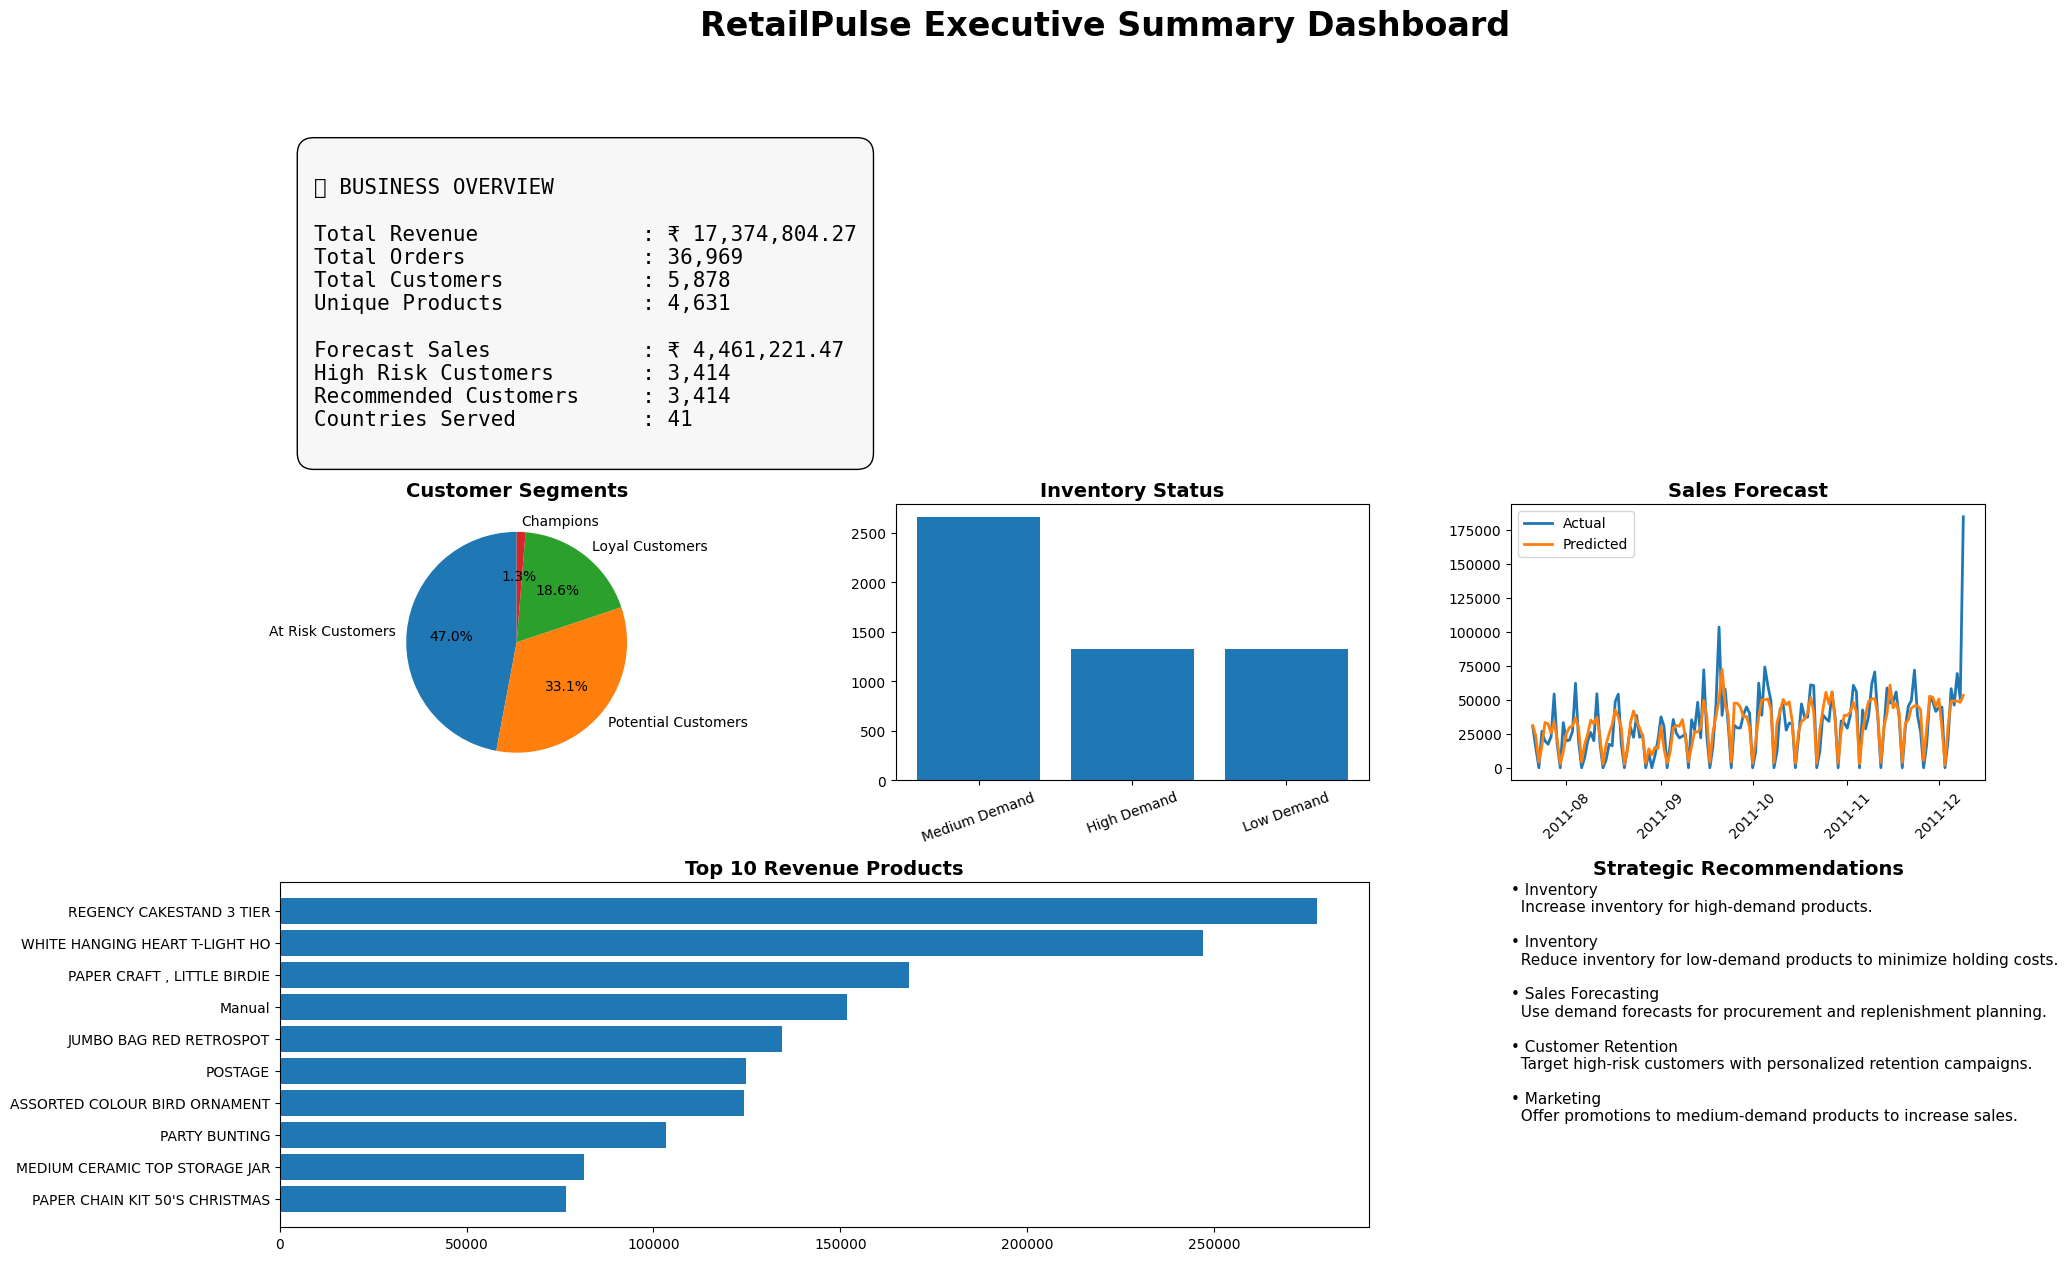

In [37]:
# ============================================================
# Dashboard 11 : Executive Summary Dashboard
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams["font.size"] = 10

fig = plt.figure(figsize=(22,14))
gs = GridSpec(
    3,
    3,
    figure=fig,
    height_ratios=[1.1,1.2,1.5],
    width_ratios=[1,1,1],
    hspace=0.35,
    wspace=0.30
)

fig.suptitle(
    "RetailPulse Executive Summary Dashboard",
    fontsize=24,
    fontweight="bold"
)

# ============================================================
# KPI PANEL
# ============================================================

ax0 = fig.add_subplot(gs[0,:])
ax0.axis("off")

forecast_sales = forecast_df["PredictedSales"].sum()

kpi_text = f"""
📊 BUSINESS OVERVIEW

Total Revenue             : ₹ {total_sales:,.2f}
Total Orders              : {total_orders:,}
Total Customers           : {total_customers:,}
Unique Products           : {retail_df['StockCode'].nunique():,}

Forecast Sales            : ₹ {forecast_sales:,.2f}
High Risk Customers       : {len(churn_df):,}
Recommended Customers     : {recommendation_df['CustomerID'].nunique():,}
Countries Served          : {retail_df['Country'].nunique():,}
"""

ax0.text(
    0.02,
    0.98,
    kpi_text,
    fontsize=15,
    va="top",
    family="monospace",
    bbox=dict(
        facecolor="#F7F7F7",
        edgecolor="black",
        boxstyle="round,pad=0.8"
    )
)

# ============================================================
# CUSTOMER SEGMENTS
# ============================================================

ax1 = fig.add_subplot(gs[1,0])

segment_counts = recommendation_df["Segment"].value_counts()

ax1.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

ax1.set_title(
    "Customer Segments",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# INVENTORY STATUS
# ============================================================

ax2 = fig.add_subplot(gs[1,1])

inventory_counts = inventory_df["InventoryStatus"].value_counts()

ax2.bar(
    inventory_counts.index,
    inventory_counts.values
)

ax2.set_title(
    "Inventory Status",
    fontsize=14,
    fontweight="bold"
)

ax2.tick_params(axis="x", rotation=20)

# ============================================================
# SALES FORECAST
# ============================================================

ax3 = fig.add_subplot(gs[1,2])

ax3.plot(
    forecast_df["Date"],
    forecast_df["ActualSales"],
    label="Actual",
    linewidth=2
)

ax3.plot(
    forecast_df["Date"],
    forecast_df["PredictedSales"],
    label="Predicted",
    linewidth=2
)

ax3.legend()

ax3.tick_params(axis="x", rotation=45)

ax3.set_title(
    "Sales Forecast",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# TOP PRODUCTS
# ============================================================

ax4 = fig.add_subplot(gs[2,0:2])

top_products = (
    retail_df
    .groupby("ProductDescription")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

ax4.barh(
    top_products.index.str[:30],
    top_products.values
)

ax4.invert_yaxis()

ax4.set_title(
    "Top 10 Revenue Products",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# BUSINESS RECOMMENDATIONS
# ============================================================

ax5 = fig.add_subplot(gs[2,2])

ax5.axis("off")

recommendation_text = ""

for _, row in business_df.iterrows():

    recommendation_text += (
        f"• {row['Category']}\n"
        f"  {row['Recommendation']}\n\n"
    )

ax5.text(
    0,
    1,
    recommendation_text,
    fontsize=11,
    va="top"
)

ax5.set_title(
    "Strategic Recommendations",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()